In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>Monk 3 dataset NN</h1>
<p>Exploring monk 3 dataset with neural network.</p>
<hr/>

In [2]:
import numpy as np
import optuna
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import tqdm as notebook_tqdm
from torch.nn import BCEWithLogitsLoss

import monk_common as mc
import nn_common as nnc
import cross_common as cr
import torch
from torch import nn
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_MEE,FOLD_VL_MEE,FOLD_TR_MEE
from cross_common import MEE,MSE,RMSE,MAE

importlib.reload(nnc)
importlib.reload(mc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [3]:
# Change this value manually for repeated evaluations: 1, 10, 20.
TRAINING_SEED = 1
#TRAINING_SEED = 10
#TRAINING_SEED = 20

nnc.set_global_seed(TRAINING_SEED)

<h3>Preparation</h3>
<hr/>

<h4>Hyperparameters and settings</h4>
<p>Default setting and hyper parameters for the NN run
</p>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interchangeability with PyTorch.
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [4]:
monk_data_set_id = 3
df_train, df_test = mc.load_set(monk_data_set_id)
X_tr, y_tr = mc.split_and_prepare_dataset(df_train)
X_ts, y_ts = mc.split_and_prepare_dataset(df_test)
mc.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


<h4>NN Architecture</h4>
<p>Defining the neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>
<p>
Some Optuna parameters such as learning rate or weight decay might have been changed to obtain better results. Such changes are reported in the notebook code with the original value commented out and the new reported below.
</p>

In [5]:
# Optuna derived configuration
optuna_learning_rate = 0.02670345308569803
#optuna_weight_decay = 0.005877438905141875 # <- optune derived parameters
optuna_weight_decay = 0.02 # <- new manual experimented value
optuna_activation = "gelu"

optuna_batch_size = 8
optuna_epochs= 1000

optuna_hidden_layers = [4] # <- optune derived parameters
#optuna_hidden_layers = [8] # <- new manual derived value
#optuna_hidden_layers = [5] # <- new manual derived value
optuna_loss_function = BCEWithLogitsLoss()

# Custom Hyperparameters
default_momentum = 0.9
default_nesterov = True

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 1

# ----- Defining model architecture --------
hidden_layers = optuna_hidden_layers
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, optuna_activation)

# The output and loss function, must be changed according to the type of task
loss_function = optuna_loss_function
output_adapter = nnc.binary_bce_adapter(threshold=0.5)

# Model implementation
model_template = nnc.build_nn_model(net, output_adapter)
# ------------------------------------------


# ---- The additional metrics ---
additional_metrics_dict = {
    MSE: (cr.mse_from_probability,min)
}
# ------------------------------------------


# -------The weight update algorithms ------
optimizer_template = partial(
    torch.optim.SGD,
    lr = optuna_learning_rate,
    momentum = default_momentum,
    nesterov = default_nesterov,
    weight_decay = optuna_weight_decay,
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-3 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------

<h3>NN Run</h3>
<hr/>

<h4>KFold</h4>
<p>Perform training and validation according to KFold strategy.</p>

In [6]:
importlib.reload(nnc)
importlib.reload(cr)

# we use stratifierd as this is a classification task
kf = cr.common_fold_strategy(stratified=True)

inner_train_params = {
    "epochs": optuna_epochs,
    "batch_size": optuna_batch_size,
    "optimizer_template": optimizer_template,
    "scheduler_template": scheduler_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": additional_metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, kf, inner_train_params
)


  
Perform fold: 0, train size: 97, val size: 25
Early stopping at epoch 89 (best VL loss: 0.1167)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 97
Validation      | samples: 25
Batch type      | mini-batch (8)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.02670345308569803, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.02}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 40 metric: loss,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 97, val size: 25
Early stopping at epoch 67 (best VL loss: 0.3354)
Train summary
--------------------------------------------------------------------------------------------

In [7]:
# recover the best median epoch
importlib.reload(nnc)
median_best_epoch = nnc.find_best_median_epochs(fold_histories)
print(median_best_epoch)

40


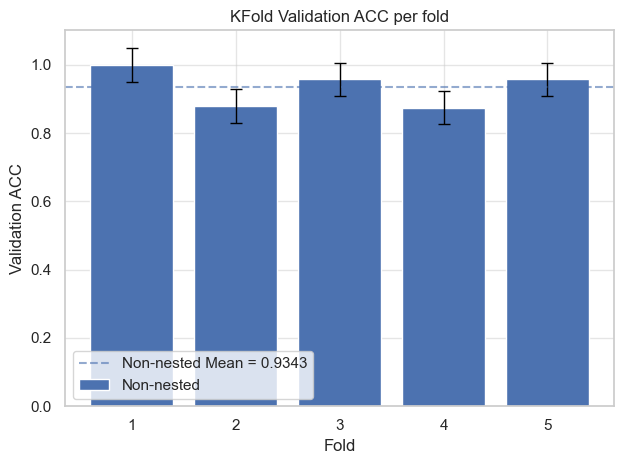

,TR,VL,|TR-VL|
Fold,,,
1,0.917526,1.000000,0.082474
2,0.948454,0.880000,-0.068454
3,0.928571,0.958333,0.029762
4,0.948980,0.875000,-0.073980
5,0.928571,0.958333,0.029762
MEAN,0.934420,0.934333,-0.000087
STD,0.012351,0.048860,0.061208


In [8]:
for metric in ["acc"]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))

<h4>Hold-out</h4>
<p>A fixed hold-out split is used to visualize the training and validation learning curves, analyze the model’s convergence and generalization behavior, and identify the best epoch through early stopping.</p>

In [9]:
importlib.reload(nnc)
model_holdout = copy.deepcopy(model_template)

inner_train_params_holdout = copy.deepcopy(inner_train_params)

train_holdout_result = nnc.train(
    model_holdout, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr)),
    **inner_train_params_holdout
)

Early stopping at epoch 74 (best VL loss: 0.3180)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 98
Validation      | samples: 24
Batch type      | mini-batch (8)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.02670345308569803, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.02}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 25 metric: loss,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------


In [10]:
epochs_holdout_tr_acc = train_holdout_result.epochs_tr_acc
epochs_holdout_vl_acc = train_holdout_result.epochs_vl_acc
epochs_holdout_tr_loss = train_holdout_result.epochs_tr_loss
epochs_holdout_vl_loss = train_holdout_result.epochs_vl_loss
epochs_holdout_tr_mse = train_holdout_result.epochs_tr_mse
epochs_holdout_vl_mse = train_holdout_result.epochs_vl_mse
epochs_holdout_grad = train_holdout_result.epochs_grad_norm
best_holdout_epoch = train_holdout_result.best_epoch

<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

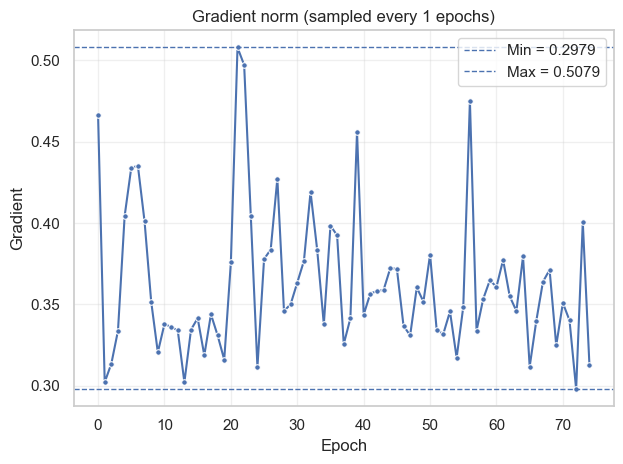

In [11]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_holdout_grad, step=1)

<Figure size 640x480 with 0 Axes>

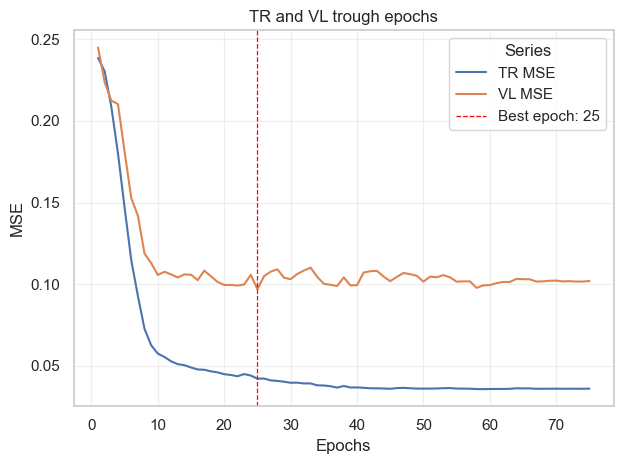

In [12]:
nnc.plot_epoch_mse(epochs_holdout_tr_mse, epochs_holdout_vl_mse, best_holdout_epoch, title="TR and VL trough epochs")

<Figure size 640x480 with 0 Axes>

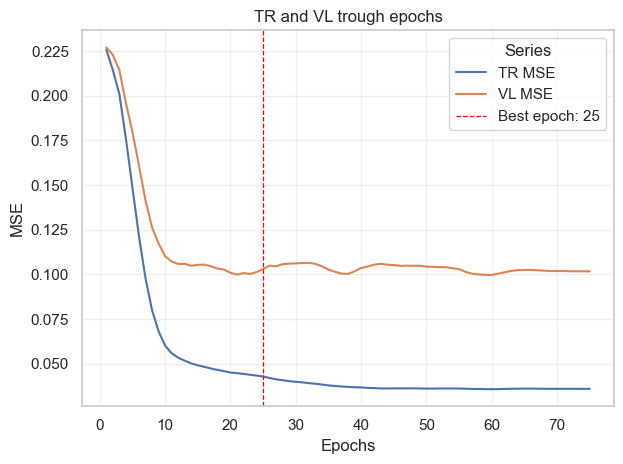

In [26]:
mc.plot_smooth_epoch_mse(epochs_holdout_tr_mse, epochs_holdout_vl_mse, best_holdout_epoch)

<Figure size 640x480 with 0 Axes>

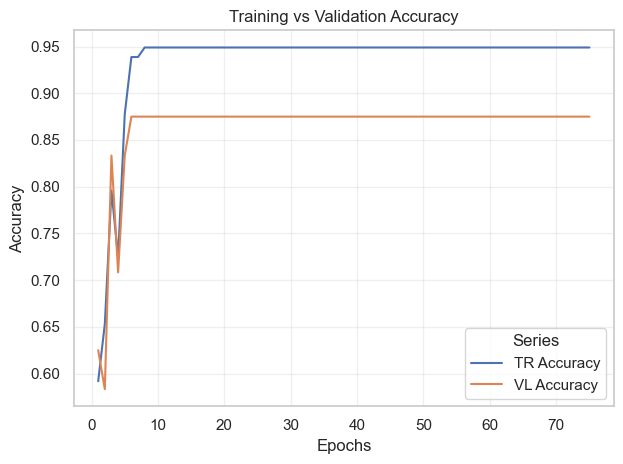

In [14]:
importlib.reload(nnc)
nnc.plot_epoch_accuracy(epochs_holdout_tr_acc, epochs_holdout_vl_acc)

<Figure size 640x480 with 0 Axes>

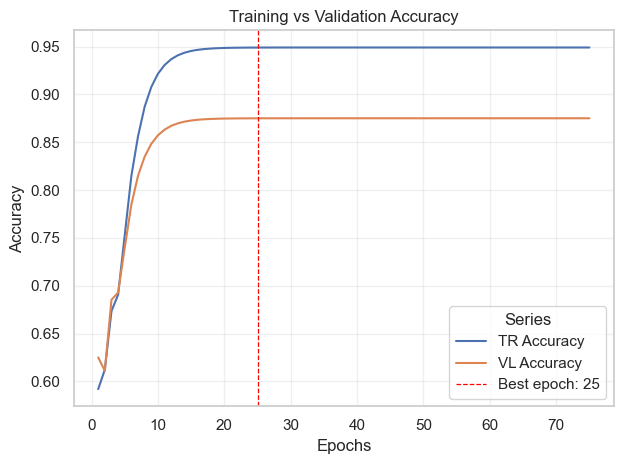

In [33]:
mc.plot_smooth_epoch_accuracy(epochs_holdout_tr_acc, epochs_holdout_vl_acc, best_holdout_epoch)

<h4>Prediction</h4>
<p>The model is reinitialized and retrained on the complete development set for the median number of best epochs estimated through K-fold cross-validation. The official test set is then used exclusively for final assessment.</p>

In [15]:
model_final = copy.deepcopy(model_template)

inner_train_params_final = copy.deepcopy(inner_train_params)

# As we are performing a retraining with the whole training set
# few parameters need to be tuned

# we don't have a validation set, so we ask the trainer to stop at the best epochs
# previously gathered from kfold (median)
inner_train_params_final["epochs"] = median_best_epoch
# no early stopping or scheduler template is needed
inner_train_params_final.pop("scheduler_template")
inner_train_params_final.pop("early_stopping_strategy")

train_full_result = nnc.train(
    model_final, nnc.FullTrainingStrategy(nnc.FeatureTargetSet(X_tr, y_tr)),
    **inner_train_params_final
)

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 40
Train           | samples: 122
Validation      | samples: None
Batch type      | mini-batch (8)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.02670345308569803, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.02}
LR Decay        | disabled
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------


In [16]:
importlib.reload(nnc)
y_pred = mc.classification_helper(model_final.predict(X_ts)) #pd.DataFrame(all_pred[0].detach().cpu().numpy())
print(classification_report(y_ts, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       204
           1       1.00      0.95      0.97       228

    accuracy                           0.97       432
   macro avg       0.97      0.97      0.97       432
weighted avg       0.97      0.97      0.97       432



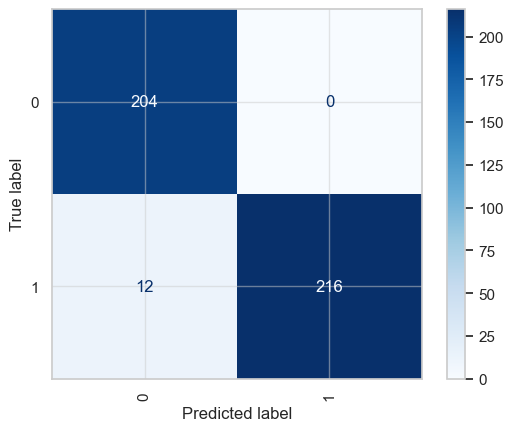

In [17]:
ConfusionMatrixDisplay.from_predictions(y_ts, y_pred, xticks_rotation='vertical', cmap='Blues');

In [18]:
print(inner_train_params)
print(inner_train_params_holdout)
print(inner_train_params_final)

{'epochs': 1000, 'batch_size': 8, 'optimizer_template': functools.partial(<class 'torch.optim.sgd.SGD'>, lr=0.02670345308569803, momentum=0.9, nesterov=True, weight_decay=0.02), 'scheduler_template': functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01), 'loss_function': BCEWithLogitsLoss(), 'early_stopping_strategy': <nn_common.EarlyStoppingStrategy object at 0x11dc06a50>, 'additional_metrics': {'mse': (<function mse_from_probability at 0x11db78eb0>, <built-in function min>), 'loss': (BCEWithLogitsLoss(), <built-in function min>)}}
{'epochs': 1000, 'batch_size': 8, 'optimizer_template': functools.partial(<class 'torch.optim.sgd.SGD'>, lr=0.02670345308569803, momentum=0.9, nesterov=True, weight_decay=0.02), 'scheduler_template': functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01), 'loss_function': BCEWithLogitsLoss(), 'early_stopping_strategy':

<h3>NN Unregolarized Run</h3>
<hr/>
<p>Varying hiperparameters to avoid regolarization obtained from Optuna hyperparameters search.
In particular:
<ul>
<li>weight decay is set to 0</li>
<li>early stopping disabled</li>
</p>

In [19]:
importlib.reload(nnc)
model_unregolarized = copy.deepcopy(model_template)

optimizer_template_unregolarized = partial(
    torch.optim.SGD,
    lr=optuna_learning_rate,
    momentum=default_momentum,
    nesterov=default_nesterov,
    weight_decay=0.0
)

inner_train_params_unregolarized = copy.deepcopy(inner_train_params)
inner_train_params_unregolarized["optimizer_template"] = optimizer_template_unregolarized
inner_train_params_unregolarized.pop("early_stopping_strategy")

train_unregolarized_result = nnc.train(
    model_unregolarized, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr)),
    **inner_train_params_unregolarized
)

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 98
Validation      | samples: 24
Batch type      | mini-batch (8)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.02670345308569803, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------


In [20]:
epochs_ur_tr_acc = train_unregolarized_result.epochs_tr_acc
epochs_ur_vl_acc = train_unregolarized_result.epochs_vl_acc
epochs_ur_tr_loss = train_unregolarized_result.epochs_tr_loss
epochs_ur_vl_loss = train_unregolarized_result.epochs_vl_loss
epochs_ur_tr_mse = train_unregolarized_result.epochs_tr_mse
epochs_ur_vl_mse = train_unregolarized_result.epochs_vl_mse
epochs_ur_grad = train_unregolarized_result.epochs_grad_norm

<Figure size 640x480 with 0 Axes>

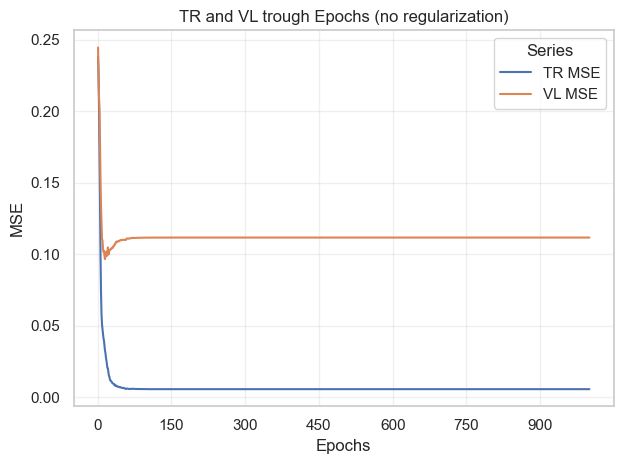

In [21]:
nnc.plot_epoch_mse(epochs_ur_tr_mse, epochs_ur_vl_mse, title="TR and VL trough Epochs (no regularization)")

<Figure size 640x480 with 0 Axes>

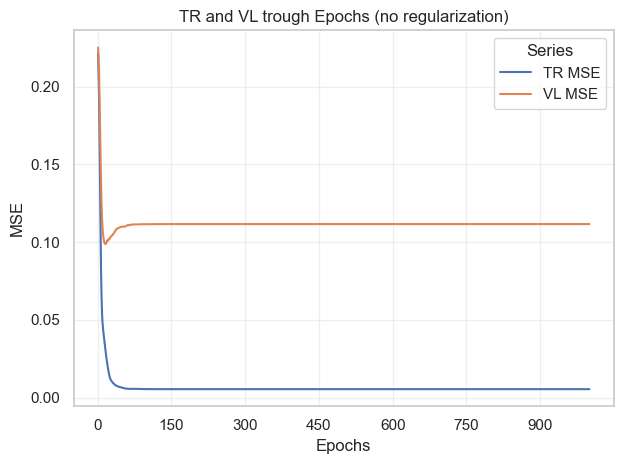

In [38]:
importlib.reload(mc)
#nnc.plot_epoch_mse(epochs_ur_tr_mse, epochs_ur_vl_mse, title="TR and VL trough Epochs (no regularization)")
mc.plot_smooth_epoch_mse(epochs_ur_tr_mse, epochs_ur_vl_mse, title="TR and VL trough Epochs (no regularization)")

<Figure size 640x480 with 0 Axes>

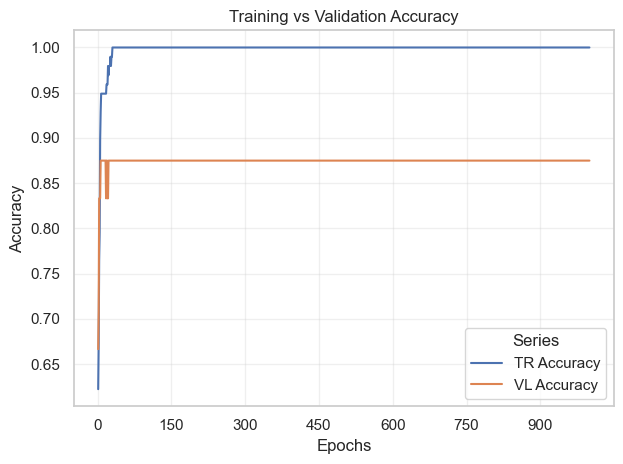

In [22]:
nnc.plot_epoch_accuracy(epochs_ur_tr_acc, epochs_ur_vl_acc)

<Figure size 640x480 with 0 Axes>

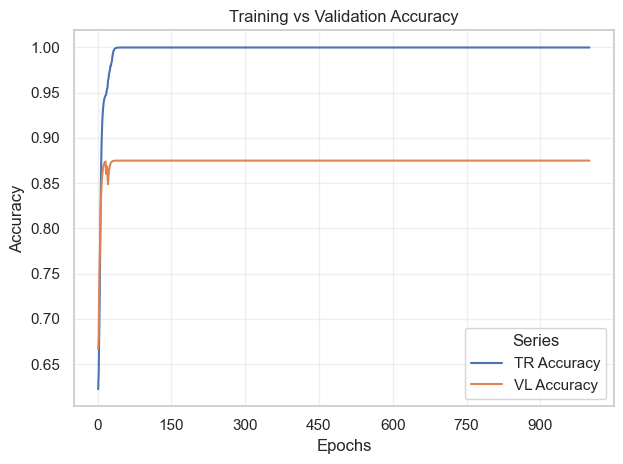

In [34]:
mc.plot_smooth_epoch_accuracy(epochs_ur_tr_acc, epochs_ur_vl_acc)

In [23]:
y_ur_pred = mc.classification_helper(model_unregolarized.predict(X_ts))
print(classification_report(y_ts, y_ur_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       204
           1       0.98      0.92      0.95       228

    accuracy                           0.94       432
   macro avg       0.94      0.95      0.94       432
weighted avg       0.95      0.94      0.94       432

